In [10]:
# import
import cv2
import matplotlib.pyplot as plt
import numpy as np

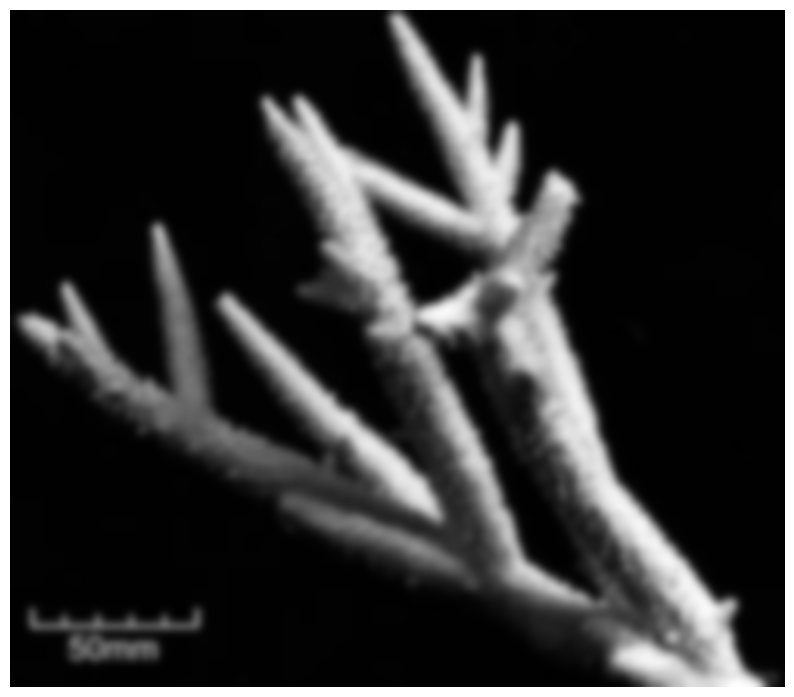

In [23]:
# edit image
image = cv2.imread("../data/raw/arborescent/intermedia1.jpg")
# resize 
height, width = image.shape[:2]
scale = 1024/width
image = cv2.resize(image, (1024, (int)(height * scale)))
# gray
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
# blur
blur = cv2.GaussianBlur(gray, (35,35), 0)

plt.figure(figsize=(10,10))
plt.imshow(blur, cmap="gray")
plt.axis("off")
plt.show()

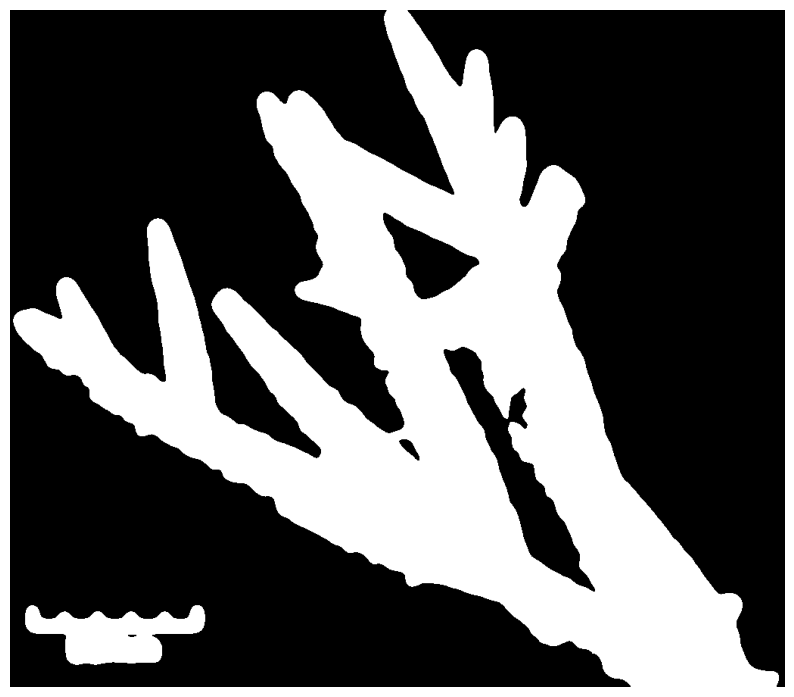

In [24]:
# threshold
(T, thresh) = cv2.threshold(blur, 20, 255, cv2.THRESH_BINARY)
plt.figure(figsize=(10,10))
plt.imshow(thresh, cmap='gray')
plt.axis('off')
plt.show()

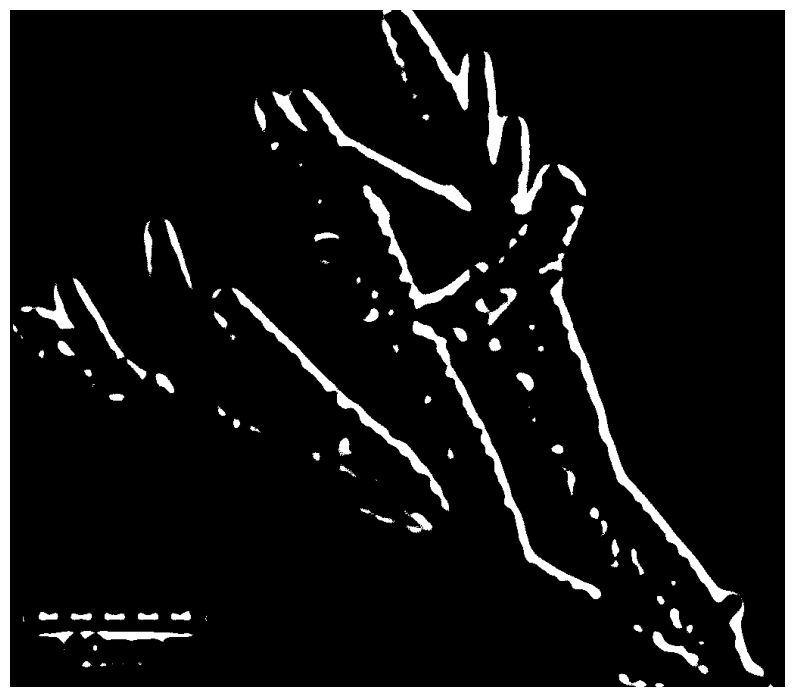

In [25]:
# adaptive threshold
a_thresh = cv2.adaptiveThreshold(blur, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY_INV, 21, 10)
plt.figure(figsize=(10,10))
plt.imshow(a_thresh, cmap='gray')
plt.axis('off')
plt.show()

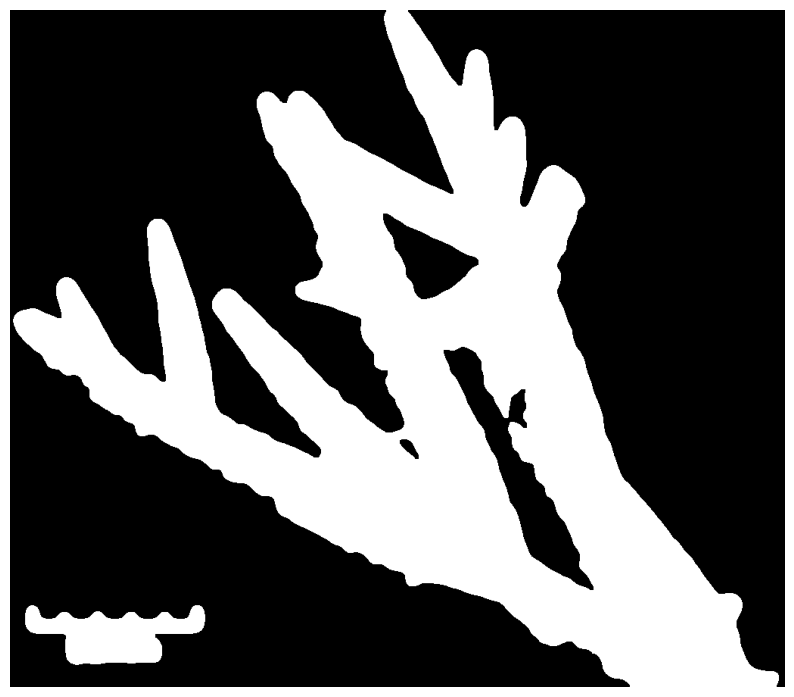

In [27]:
# cleaning
kernel = np.ones((5, 5), np.uint8)
open = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
close = cv2.morphologyEx(open, cv2.MORPH_CLOSE, kernel)
mask = close
plt.figure(figsize=(10,10))
plt.imshow(mask, cmap='gray')
plt.axis('off')
plt.show()

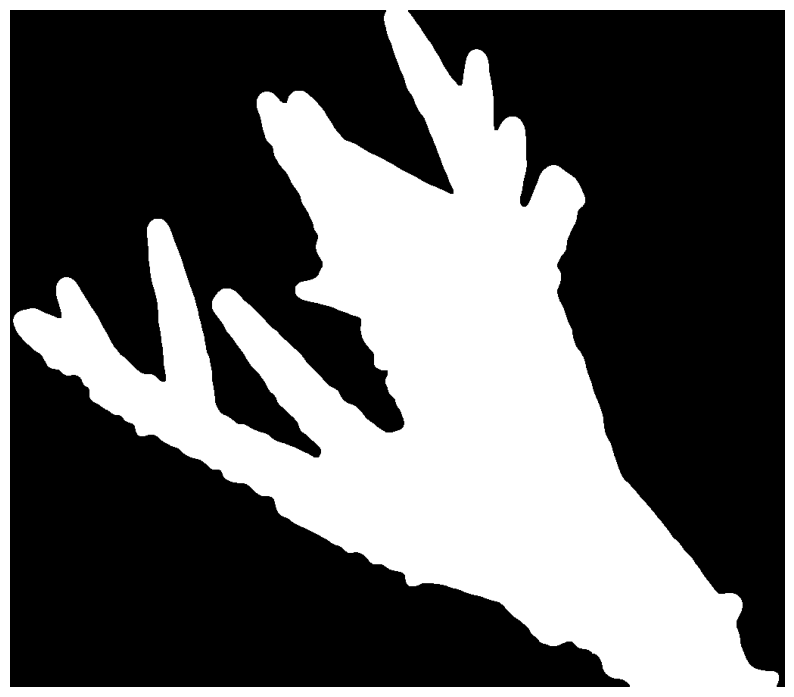

In [29]:
# remove the scale rulers by contouring
contours, hierarchy = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE) # find white shape boundaries
# only keep largest shape aka coral branch
if contours:
    largest_c = max(contours, key=cv2.contourArea)
    # draw largest
    largest_mask = np.zeros_like(mask)
    cv2.drawContours(largest_mask, [largest_c], 0, 255, -1)
# show
plt.figure(figsize=(10,10))
plt.imshow(largest_mask, cmap='gray')
plt.axis('off')
plt.show()
